**M2 OSAE**


**Signaux et Systèmes: Traitement du Signal - 2025 - 2026**

# DM noté

## A rendre pour le 08 décembre 2025

**Nom et prénom: SIVARAJAH Monija**



## Note:
Additionner les cellules code ou texte supplémentaires si nécessaire pour effectuer votre travail.

## Modalité de remise du controle
- Veuillez rendre un fichier pdf de préférence (vérifier son contenu avant envoi et que rien ne manque...).
- Inclure votre nom dans le nom du fichier
- Envoyer votre fichier par email le 08 décembre dernier délai.

# Partie 1


# Introduction

Le fichier "donnees.dat" contient des mesures effectuées pendant 2 secondes sur une galaxie (objet ponctuel). La premiere colonne donne le temps (en seconde), la deuxieme, la valeur du signal (en Volts). Ces mesures ont été effectuées avec une méthode de modulation ON/OFF, c'est à dire en observant alternativement le fond du ciel, puis la galaxie + le fond du ciel avec les caractéristiques suivantes:

- Nous avons utilisé une modulation carré avec une fréquence de 2 Hz.
- Les mesures sont indépendantes les unes des autres.
- Nous supposons que le fond est constant sur tout le ciel.


**Q1:** Après avoir importé et tracé le signal en fonction du
temps en secondes, calculer la période (fréquence) d'échantillonge du signal. Peut on, à partir de ces données brutes et de ce graphique, faire une estimation du signal émis par cette galaxie, du bruit et donner un rapport signal sur bruit?

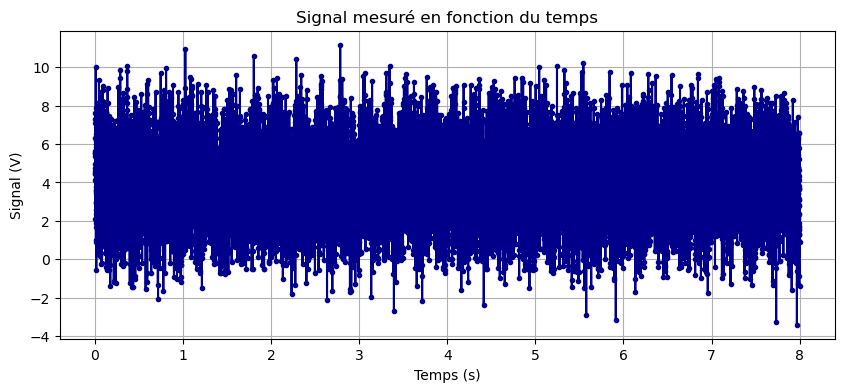

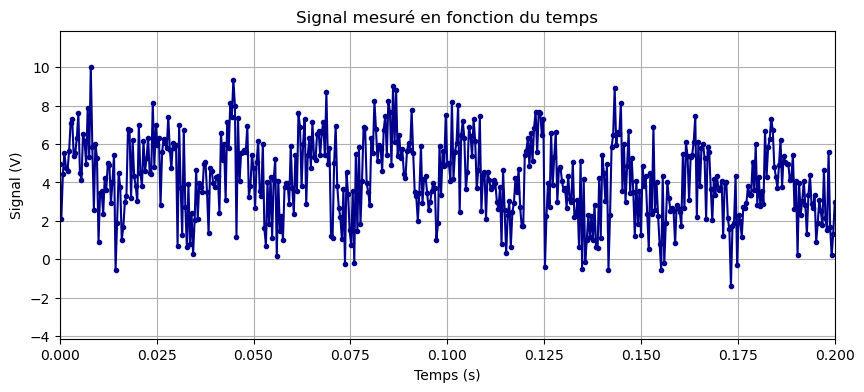

Période d'échantillonnage Te = 4.00e-04 s
Fréquence d'échantillonnage fe = 2.50e+03 Hz
SNR = 2.12e+00


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Données
data = np.loadtxt("donneescontrole.dat")
t = data[:,0]
s = data[:,1]

# Tracé du signal 
plt.figure(figsize=(10,4))
plt.plot(t, s, marker=".", linestyle="-", color="darkblue")
plt.xlabel("Temps (s)")
plt.ylabel("Signal (V)")
plt.title("Signal mesuré en fonction du temps")
plt.grid()
plt.show()

# Zoom sur le signal
plt.figure(figsize=(10,4))
plt.plot(t, s, marker=".", linestyle="-", color="darkblue")
plt.xlim(0,0.2)
plt.xlabel("Temps (s)")
plt.ylabel("Signal (V)")
plt.title("Signal mesuré en fonction du temps")
plt.grid()
plt.show()


# Période et fréquence d'échantillonnage
dt = np.diff(t)
Te = np.mean(dt)
fe = 1 / Te

print(f"Période d'échantillonnage Te = {Te:.2e} s")
print(f"Fréquence d'échantillonnage fe = {fe:.2e} Hz")


# SNR
moy = np.mean(s)
std = np.std(s)
SNR = moy/std

print(f"SNR = {SNR:.2e}")

<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
### Estimation du signal de la galaxie 

Le graphique précédent représente clairement la modulation ON/OFF. Les données étant très bruitées, pour l'instant il est impossible d'en déduire le signal de la galaxie. 

---

### Estimation du bruit

Le bruit N peut être estimé par l’écart-type du signal S: 

$$N = \sigma_{S}$$

---

### Calcul du rapport signal sur bruit

Avec les données brutes, on peut estimer le SNR en prenant la moyenne du signal ainsi que son écart-type. 
$$SNR = \frac{\langle s \rangle}{\sigma_S}$$

On obtient alors un SNR de $2.12$.



**Q2:** En appliquant une convolution sur le signal, qu'observez vous après avoir tracé le résultat?

A partir de ce résultat, expliquez comment la valeur du signal correspondant à l'emission de la galaxie observée peut etre calculée. Comment calculer le rapport Signal sur Bruit de cette mesure?

**Note:** Vous pouvez appliquer le type de convolution que vous voulez en optimisant les paramètres en fonction des résultats.

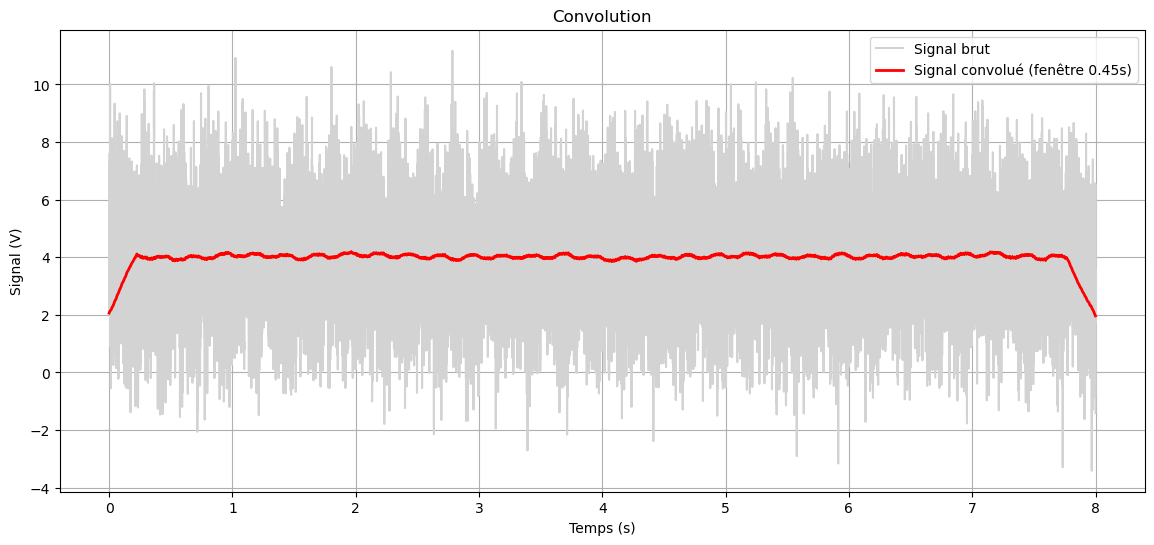

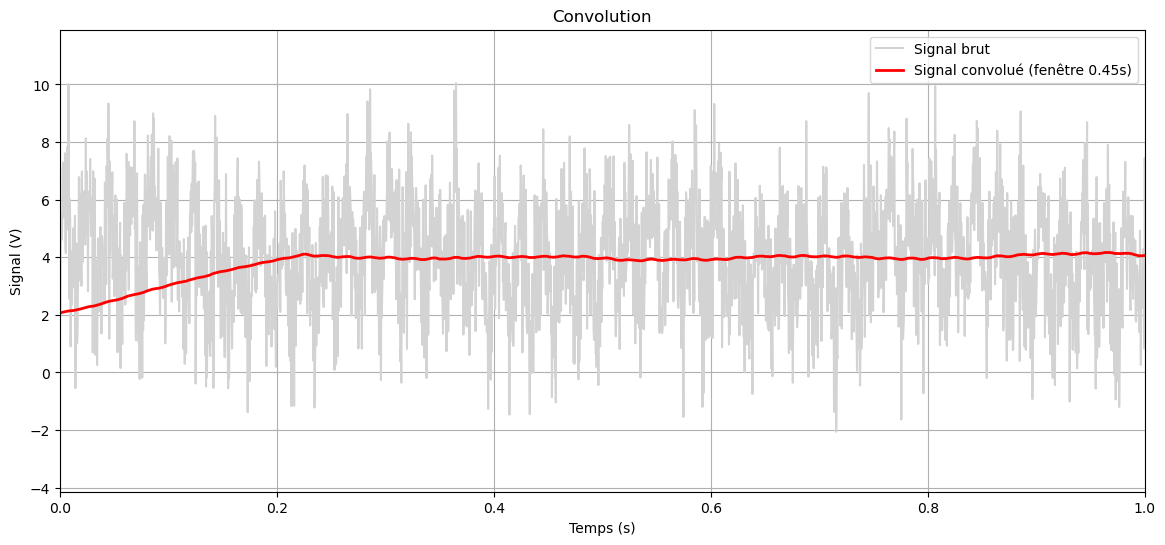

In [2]:
# Convolution avec une fenêtre glissante
largeur_fenetre_sec = 0.45  # on ajusté de sorte à voir les modulations sans présence de bruit
largeur_fenetre_pts = int(largeur_fenetre_sec * fe)

noyau = np.ones(largeur_fenetre_pts) / largeur_fenetre_pts

# Convolution
signal_conv = np.convolve(s, noyau, mode="same")

# Tracé
plt.figure(figsize=(14, 6))
plt.plot(t, s, color="lightgray", label="Signal brut")
plt.plot(t, signal_conv, color="red", linewidth=2, label=f"Signal convolué (fenêtre {largeur_fenetre_sec}s)")
plt.xlabel("Temps (s)")
plt.ylabel("Signal (V)")
plt.title("Convolution")
plt.legend()
plt.grid()
plt.show()

# Tracé zoom
plt.figure(figsize=(14, 6))
plt.plot(t, s, color="lightgray", label="Signal brut")
plt.plot(t, signal_conv, color="red", linewidth=2, label=f"Signal convolué (fenêtre {largeur_fenetre_sec}s)")
plt.xlabel("Temps (s)")
plt.ylabel("Signal (V)")
plt.title("Convolution")
plt.xlim(0, 1)
plt.legend()
plt.grid()
plt.show()




<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
### Observation 
Grâce à la convolution, on a réussi à réduire le bruit.  Cependant, des pics apparaissent au début et à la fin du signal, ce qui caractérise des effets de bord causés par la fenêtre glissante.

---
### Signal de la galaxie 
Le signal convolué fait apparaître une alternance de niveaux ON et OFF:

- Les niveaux ON correspondent à la mesure de la Galaxie + Fond du ciel.
  
- Les niveaux OFF correspondent à la mesure du Fond du ciel seul.

Pour obtenir la valeur du signal émis par la galaxie seule, il faut effectuer une soustraction des moyennes de ces niveaux :

$$S_{galaxie} = \langle S_{ON} \rangle − \langle S_{OFF} \rangle$$

Cela revient à faire : $(S_{galaxie} + S_{fond}) − S_{fond}$


---

### Rapport signal sur bruit
Le bruit correspond à l'écart-type autour du niveau OFF: $\sigma = std(S_{OFF})$

Le rapport signal sur bruit s'obtient ainsi : $SNR = \frac{S_{galaxie}}{\sigma}$



**Q3:** Faire le calcul de la valeur du signal émis par la galaxie, l'erreur sur sa mesure, et le rapport signal sur bruit obtenues après votre convolution.

In [3]:
## Définition du seuil de séparation
# On utilise la moyenne globale du signal convolué comme seuil
seuil = np.mean(signal_conv)

## Gestion des effets de bord 
nb_points_bords = int(0.15 * fe) # ignore les premiers et derniers 15 % de points
mask_temps_valide = np.zeros_like(signal_conv, dtype=bool)
mask_temps_valide[nb_points_bords:-nb_points_bords] = True

## Création des masques 
mask_on = (signal_conv > seuil) & mask_temps_valide
mask_off = (signal_conv <= seuil) & mask_temps_valide

## Extraction des données
valeurs_on = signal_conv[mask_on]
valeurs_off = signal_conv[mask_off]


# Moyennes 
moyenne_on = np.mean(valeurs_on) # Signal Galaxie + Fond du ciel
moyenne_off = np.mean(valeurs_off)  # Fond du Ciel

# Estimation du bruit
bruit = np.std(valeurs_off)

# Signal de la galaxie
signal_galaxie = moyenne_on - moyenne_off

# Rapport Signal sur Bruit
snr = signal_galaxie / bruit

print(f"Moyenne ON : {moyenne_on:.2e}")
print(f"Moyenne OFF : {moyenne_off:.2e}")  
print(f"Signal de la galaxie estimé : {signal_galaxie:.2e} V")
print(f"Bruit : {bruit:.2e} V")
print(f"Rapport Signal/Bruit : {snr:.2e}")
      

Moyenne ON : 4.05e+00
Moyenne OFF : 3.91e+00
Signal de la galaxie estimé : 1.35e-01 V
Bruit : 1.05e-01 V
Rapport Signal/Bruit : 1.29e+00


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
La méthode de convolution temporelle nous a permis de passer d'un signal brut inexploitable (où le signal était noyé dans le bruit) à une mesure quantifiée.
Cependant, avec un SNR de 3.63, la mesure reste entachée d'une incertitude significative due au bruit basse fréquence que la convolution n'a pas pu éliminer. Les effets de bord contribuent également à cette limitation.

**Q4:** Après avoir appliqué une Transformée de Fourier sur les données dans le fichier, représentez les résultats. Décrire, interpréter et expliquer ce que vous observez dans le spectre de la mesure.

**Conseil:** Représentez le graphique de la TF à plusieurs échelles afin d'observer celui ci en détail.

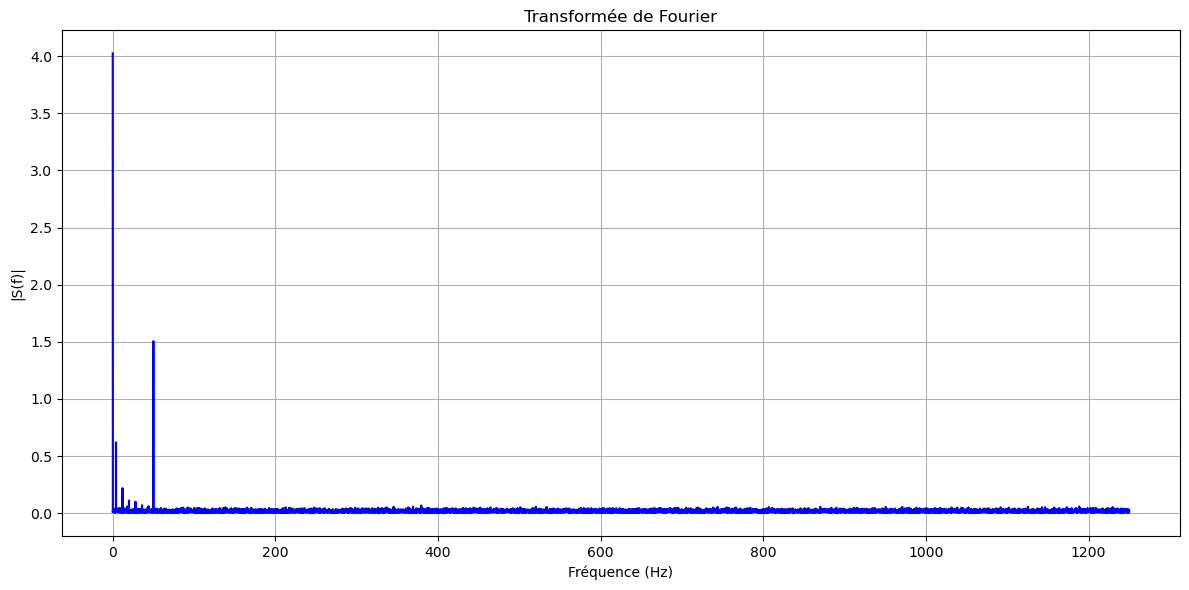

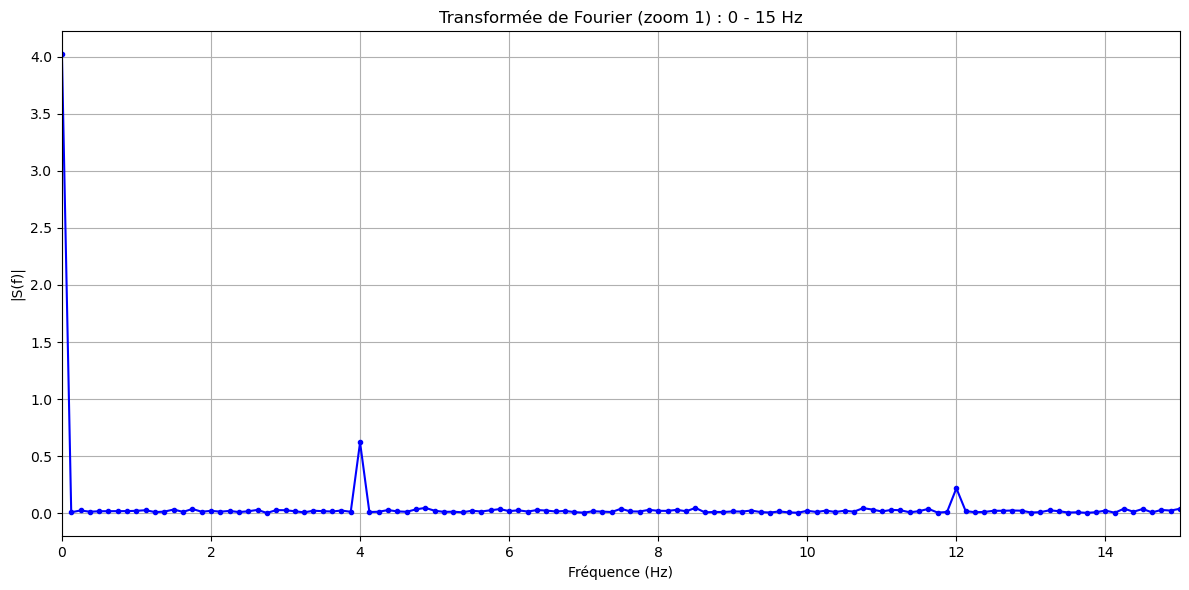

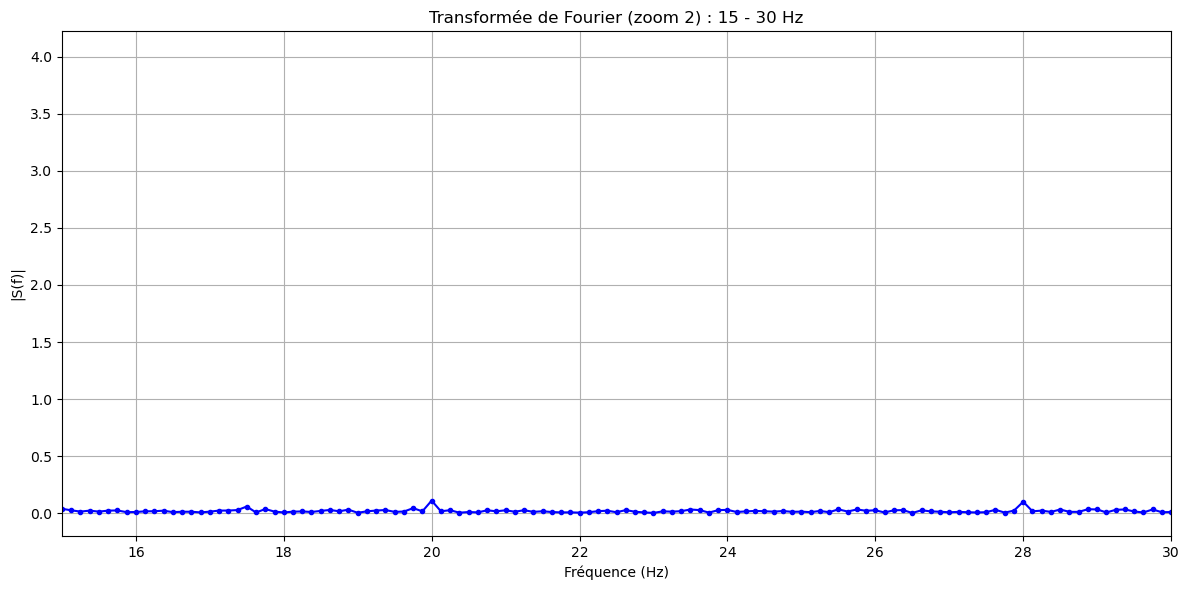

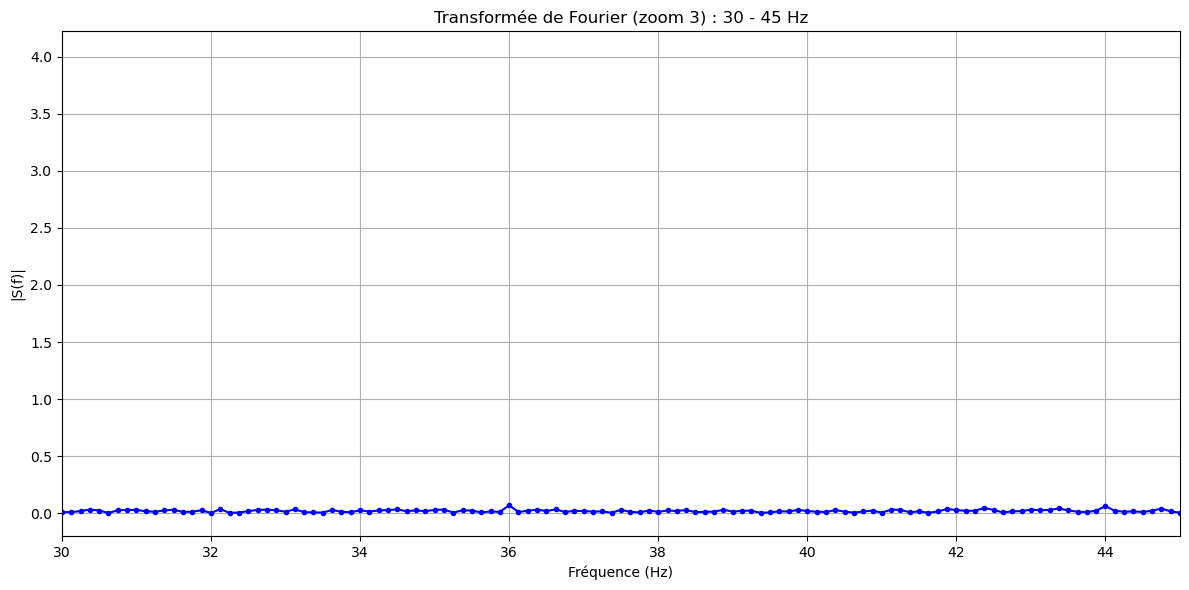

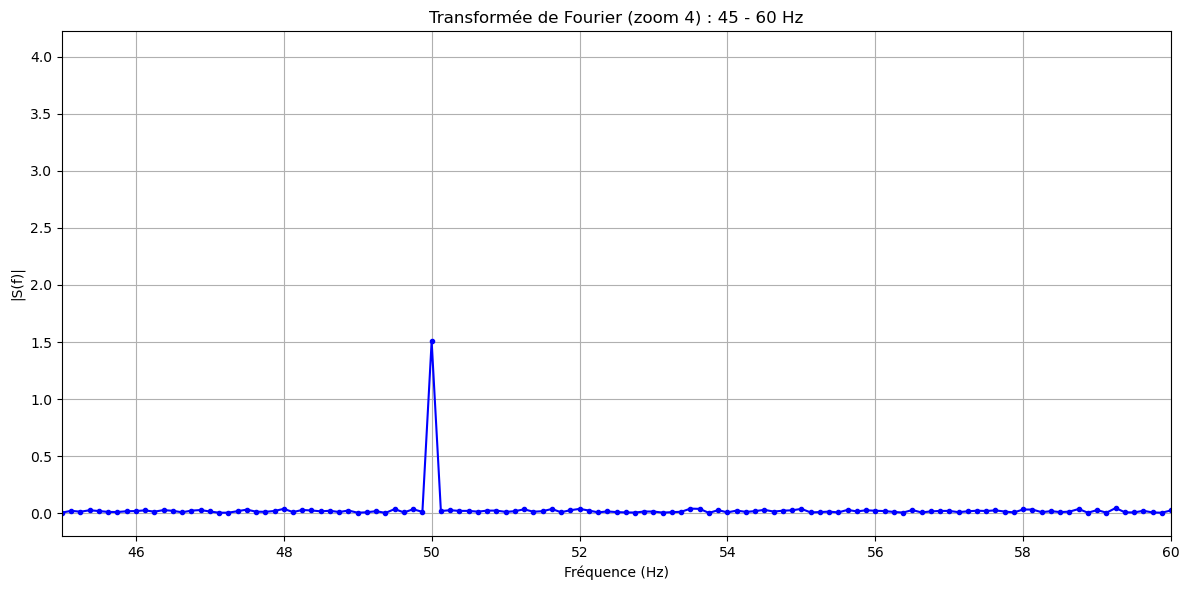

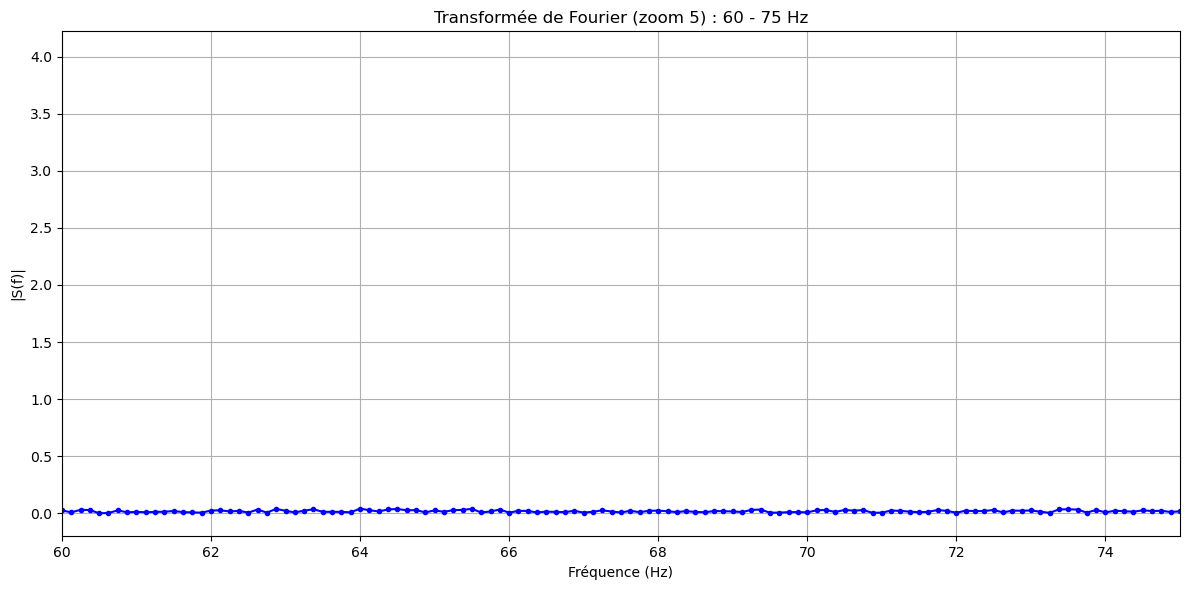

In [4]:
# Calcul de la FFT
n = len(s)
tf = np.fft.fft(s)
freqs = np.fft.fftfreq(n, d=Te)

# Normalisation de l'amplitude 
amplitude = np.abs(tf) * 2 / n 
amplitude[0] = amplitude[0] / 2 

# Sélection des fréquences positives pour l'affichage
mask_pos = freqs >= 0
freqs_pos = freqs[mask_pos]
ampl_pos = amplitude[mask_pos]


# Définition de la largeur de chaque fenêtre de zoom 
step = 15
max_freq = 75


plt.figure(figsize=(12, 6))
plt.plot(freqs_pos, ampl_pos, "-", color="blue")
plt.title("Transformée de Fourier")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("|S(f)|")
plt.grid()
plt.tight_layout()
plt.show()


for i, start in enumerate(range(0, max_freq, step)):
    end = start + step
    
    plt.figure(figsize=(12, 6))
    plt.plot(freqs_pos, ampl_pos, ".-", color="blue")
    plt.xlim(start, end) 
    plt.title(f"Transformée de Fourier (zoom {i+1}) : {start} - {end} Hz")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("|S(f)|")
    plt.grid()
    plt.tight_layout()
    plt.show()



<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">

Sur le spectre du signal on observe des pics à plusieurs fréquences (0, 4, 12, 20, 28, 36, 44, 50 Hz).

- Le pic en $f = 0$ Hz avec la plus grande amplitude correspond à la composante DC (continue) du signal. Il s'agit de la moyenne du signal prenant surtout en compte le fond du ciel :  $DC =\langle s \rangle$. Cette composante est très élevée en raison du fond du ciel.

- Bien que l'énoncé annonce une modulation à 2 Hz, l'analyse spectrale révèle une fréquence fondamentale à 4 Hz.

- Toutes les autres fréquences (12, 20, 28 Hz...) correspondent aux fréquences harmoniques.

En ce qui concerne le bruit, il reste tout de même présent sur le spectre.



**Q5:** La modulation ON/OFF du signal étant carré, comment celle ci peut se décomposer en somme de sinus et de cosinus? Retrouver, à partir du spectre, la valeur de l'emission de la galaxie, ainsi que celle du fond du ciel.

<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
### Modulation ON/OFF et décomposition en Fourier
La modulation ON/OFF du signal étant carrée (fréquence $f_m = 2 \text{ Hz})$, elle peut se décomposer en somme de sinus impairs grâce à une série de Fourier :

$$
x(t) = S_{\text{fond}} + \frac{4 S_{\text{gal}}}{\pi} \sum_{n=1,3,5,...}^{\infty} \frac{1}{n} \sin(2 \pi n f_m t)
$$

où :  
- $S_{\text{fond}}$ est le niveau du fond du ciel,  
- $S_{\text{gal}}$ est l’amplitude de l’émission de la galaxie,  
- $n = 1, 3, 5, \dots$ correspond aux harmoniques impaires de la modulation carrée.


### Extraction des valeurs à partir du spectre

1. **Fond du ciel** : correspond à la **composante continue (DC)** du spectre, soit la moyenne du signal.

$$
S_{\text{fond}} = \text{moyenne du signal mesuré}
$$

2. **Émission de la galaxie** : correspond à la fréquence fondamentale (fréquence $f_m = 4$ Hz). On utilise la relation :

$$
S_{\text{gal}} = \frac{\pi}{4} \times \text{Amplitude du spectre à } f_m
$$

Ainsi, en réalisant une **FFT du signal**, on retrouve directement le fond et l’émission de la galaxie à partir de leurs composantes spectrales respectives.

In [5]:
# On cherche l'indice précis correspondant à 0 Hz et à la fondamentale (4 Hz)
idx_0 = 0
idx_fond = np.argmin(np.abs(freqs_pos - 4.0)) # On prend le pic à 4 Hz

A_0 = ampl_pos[idx_0]       # Amplitude DC (Composante continue)
A_1 = ampl_pos[idx_fond]    # Amplitude de la fondamentale

# S_gal = A1 * (pi / 2)
S_gal_fft = A_1 * (np.pi / 4)

# Fond = A0 - (S_gal / 2)
Fond_fft = A_0 - (S_gal_fft / 4)


print(f"Signal Galaxie : {S_gal_fft:.2e} V")
print(f"Fond du Ciel  : {Fond_fft:.2e} V")


Signal Galaxie : 4.87e-01 V
Fond du Ciel  : 3.90e+00 V


**Q6:** Afin de réduire le bruit et enlever les effets systématiques, vous allez appliquer un f£iltre fréquentiel.

A vous de définir ce filtre: Quel est le signal d'intéret à conserver? Vous pouvez tout simplement mettre à zèro la partie du spectre qui ne vous interesse pas. Expliquer et justifier votre méthode.


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
### Identification du signal d'intérêt :

L'analyse spectrale (Q4) révèle que l'énergie du signal est concentrée sur des fréquences discrètes, signature d'une modulation carrée à 4 Hz :
* **0 Hz (DC) :** Fondamentale pour le niveau du Fond du Ciel.
* **4 Hz (Fondamentale) :** Contient la majorité de l'énergie du signal Galaxie.
* **Harmoniques  (12 Hz, 20 Hz, 28 Hz) :** Ces pics sont visibles sur le spectre. Ils contiennent les détails qui donnent au signal sa forme "carrée" (les transitions rapides).


### Méthode de filtrage choisie :

Nous allons appliquer un filtre "peigne" (multi-passe-bande).
Le principe est de créer un masque spectral qui vaut $1$ uniquement autour des fréquences identifiées et $0$ partout ailleurs (bruit).
* **Fréquences conservées :** 0 Hz, 4 Hz, 12 Hz, 20 Hz, 28 Hz (ainsi que leurs symétriques négatifs : -4, -12, etc.).
* **Fréquences rejetées :** Tout le reste du spectre (le bruit entre les pics).



Le bruit est étalé sur toutes les fréquences, alors que le signal utile est confiné dans ces pics précis.
En ne gardant que ces fréquences (et leurs symétriques), nous conservons toute l'information visible du signal tout en éliminant le bruit présent sur les autres fréquences inutiles. Cela permet d'optimiser le SNR tout en respectant la forme temporelle du signal.

**Q7:** Après avoir appliqué sur le spectre le fitre fréquentiel que vous aurez défini, effectuez la TF inverse. Représentez le signal filtré ainsi obtenu et comparez le avec le résultat de la convolution que vous avez effectuée auparavant.

Décrivez et expliquez ce que vous observez.

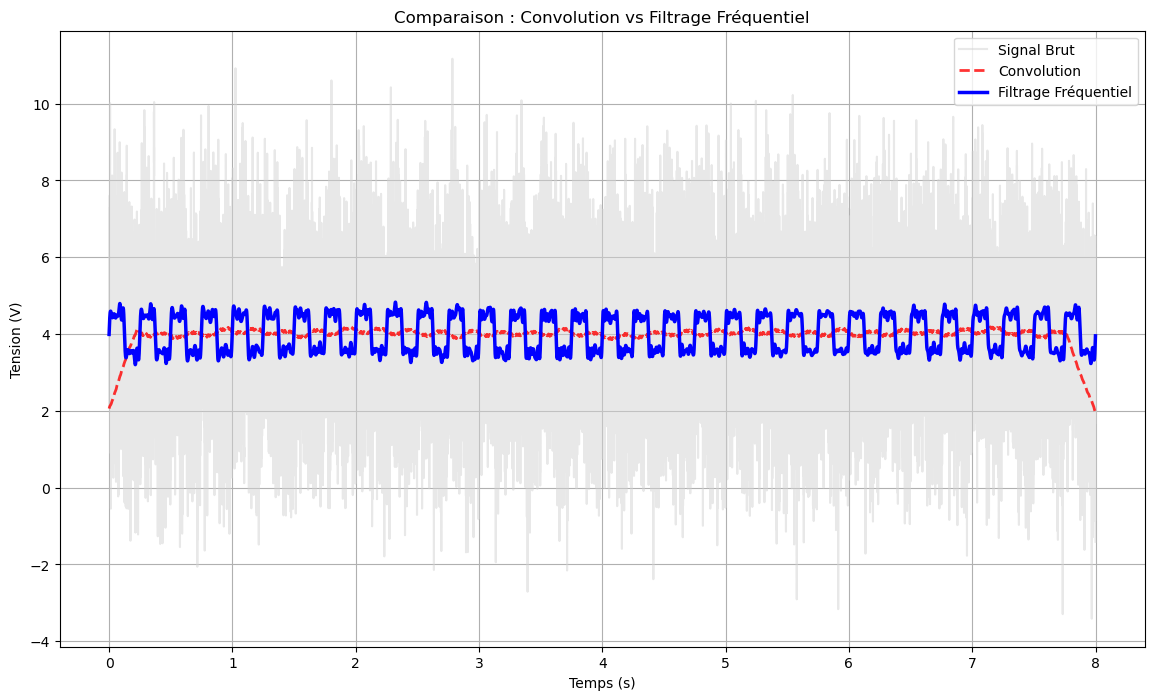

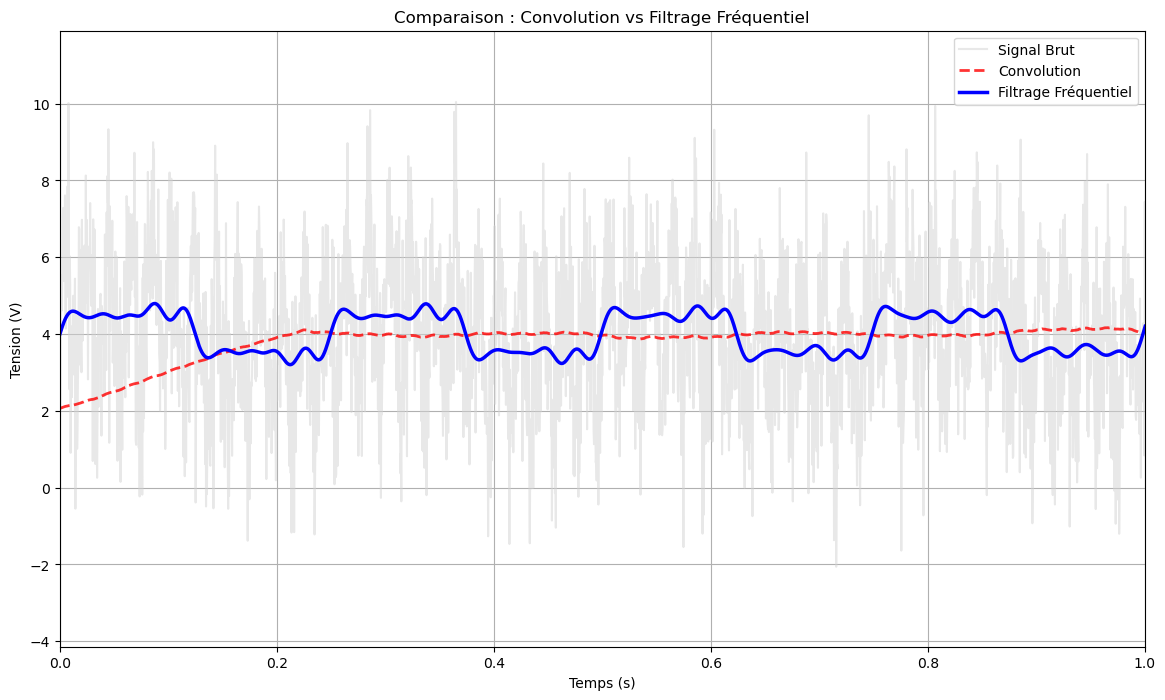

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Création du masque 
mask_filter = np.zeros_like(tf)


# Fréquences à conserver : 0 (Fond), 4 (Signal) et harmoniques impaires
frequences_cibles = [0, 4, 12, 20, 28, 36, 44] # On ne prend pas en compte le 50
tol = 0.5 

for f_cible in frequences_cibles:
    # Sélection des pics (fréquences positives et négatives)
    indices = np.abs(np.abs(freqs) - f_cible) < tol
    mask_filter[indices] = 1


# Application du filtre et TF Inverse
tf_filtered = tf * mask_filter
signal_filtered = np.real(np.fft.ifft(tf_filtered)) # Retour au domaine temporel



plt.figure(figsize=(14, 8))
plt.plot(t, s, color='lightgray', alpha=0.5, label='Signal Brut')
plt.plot(t, signal_conv, 'r--', linewidth=2, alpha=0.8, label='Convolution')
plt.plot(t, signal_filtered, 'b-', linewidth=2.5, label='Filtrage Fréquentiel')
plt.xlabel('Temps (s)')
plt.ylabel('Tension (V)')
plt.title('Comparaison : Convolution vs Filtrage Fréquentiel')
plt.legend(loc='upper right')
plt.grid()
plt.show()

plt.figure(figsize=(14, 8))
plt.plot(t, s, color='lightgray', alpha=0.5, label='Signal Brut')
plt.plot(t, signal_conv, 'r--', linewidth=2, alpha=0.8, label='Convolution')
plt.plot(t, signal_filtered, 'b-', linewidth=2.5, label='Filtrage Fréquentiel')
plt.xlabel('Temps (s)')
plt.ylabel('Tension (V)')
plt.title('Comparaison : Convolution vs Filtrage Fréquentiel')
plt.legend(loc='upper right')
plt.grid()
plt.xlim(0, 1.0)
plt.show()



**Q8:** Refaire le calcul de la moyenne du signal emis par la galaxie, l'erreur sur la mesure, et le rapport signal sur bruit obtenues après filtrage. Comparer avec les résultats précedemment obtenus avec la convolution. 

In [7]:

# On utilise le seuil moyen pour séparer 
seuil = np.mean(signal_filtered)

# On prend 10% de l'amplitude estimée comme marge
marge = 0.1 * np.std(signal_filtered) 

# Exclusion des bords temporels (pour éviter les effets de bord du début/fin)
mask_temps = (t > 0.1) & (t < t[-1] - 0.1)

# Masques pour isoler les plateaux
mask_haut = (signal_filtered > seuil + marge) & mask_temps
mask_bas = (signal_filtered < seuil - marge) & mask_temps

# Calcul des moyennes et écarts-types
val_haut = signal_filtered[mask_haut]
val_bas = signal_filtered[mask_bas]

# Moyennes
moyenne_haut = np.mean(val_haut)
moyenne_bas = np.mean(val_bas)

# Bruit 
sigma_haut = np.std(val_haut)
sigma_bas = np.std(val_bas)
bruit_filtre = (sigma_haut + sigma_bas) / 2

# Calcul du Signal et du SNR
signal_galaxie_filtre = moyenne_haut - moyenne_bas
snr_filtre = signal_galaxie_filtre / bruit_filtre


print("RÉSULTATS FILTRAGE FRÉQUENTIEL")
print(f"Moyenne HAUT (Galaxie + Fond) : {moyenne_haut:.2e} V")
print(f"Moyenne BAS (Fond seul)       : {moyenne_bas:.2e} V")
print(f"Signal Galaxie détecté        : {signal_galaxie_filtre:.2e} V")
print(f"Erreur (Bruit résiduel)       : {bruit_filtre:.2e} V")
print(f"Rapport Signal sur Bruit      : {snr_filtre:.2e}")

gain = snr_filtre / snr

print("\nCOMPARAISON")
print(f"SNR Convolution   : ~ {snr:.2e}")
print(f"Amélioration (Facteur de gain): x {gain:.2e}")


RÉSULTATS FILTRAGE FRÉQUENTIEL
Moyenne HAUT (Galaxie + Fond) : 4.50e+00 V
Moyenne BAS (Fond seul)       : 3.55e+00 V
Signal Galaxie détecté        : 9.53e-01 V
Erreur (Bruit résiduel)       : 1.17e-01 V
Rapport Signal sur Bruit      : 8.15e+00

COMPARAISON
SNR Convolution   : ~ 1.29e+00
Amélioration (Facteur de gain): x 6.34e+00


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
La convolution  est un filtre "passe-bas"  : elle laisse passer tout le bruit contenu dans les basses fréquences. À l'inverse, le filtrage fréquentiel agit comme un "peigne" : il ne conserve que les fréquences précises où se trouve l'énergie de la galaxie (4, 12, 20 Hz...) et supprime tout le reste du spectre. En éliminant le bruit situé entre les harmoniques, on augmente le SNR comme on peut le remarquer ci-dessus.

# Partie 2

Soit un instrument embarqué sur une sonde spatiale à destination d’un astéroïde. L’instrument doit évaluer la teneur en Fer de l’astéroïde à l’aide de mesures réalisées au contact de la surface. On caractérise dans un 1er temps la précision de l’instrument avant intégration sur le satellite. On réalise une série de 200 mesures de la teneur en Fer sur un même échantillon. Les résultats sont donnés dans la figure 1 donnée dans un fichier séparé.

**Q9:** Le % en Fer de l’échantillon est connu : 12%. Expliquer pourquoi l’instrument est biaisé. On considérera par la suite ce biais comme additif et constant. Donner la valeur de ce biais systématique.


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">

**Instrument biaisé :**

La valeur réelle connue de l'échantillon est de $12$ ‰. En regardant la figure 1, on constate que le nuage de points n'est pas centré sur 12 %. Au contraire, la quasi-totalité des mesures est supérieure à 12 %. En raison de cette différence, l'instrument est biaisé.

---
**Valeur du biais systématique :**

Le biais correspond à la différence entre la moyenne des mesures et la valeur réelle.
$$
Biais = m_{mesures} - m_{reelle} = 15 - 12 = + 3 \%
$$

Le biais de l'instrument est donc de + 3 \%, il y a donc surrestimage de la teneur en Fer.

**Q10:** On réalise un histogramme des valeurs de % en Fer obtenues pendant cette série de mesures. Une loi Normale est ajustée sur cet histogramme qui est donné dans la figure 2 (fichier séparé).

Déterminer par une lecture graphique la valeur de l’écart-type de cette distribution. En déduire les caractéristiques de l’erreur aléatoire additive, centrée sur 0, associée à cet instrument.


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">

**Valeur de l'écart-type de la distribution :**

La hauteur maximale de la courbe est $H_{max} = 25$. L'écart-type à 60 % se calcule ainsi : $0.6 \times H_{max} = 15$. Si on trace la droite verticale en $y = 15$, les deux points sont $x_1 = 13.8$ et $x_2 = 16.1$. On a donc $2 \sigma = x_2 - x_1 = 2.3$ soit $\sigma = 0.9$.

---

**Caractéristiques de l'erreur :**

L'erreur aléatoire est additive, centrée sur $0$, et suit une loi normale d'écart-type $\sigma=0.9\%$.


**Q11:** Une durée totale de 3 minutes et 45 secondes est nécessaire pour chaque mesure. Le scénario initial de la mission prévoit un atterrissage d’une heure de la sonde sur l’astéroïde.

Combien de mesures peut-on réaliser dans ce contexte ? A l’issu de cette série de mesures, quelle sera l’étendue de l’intervalle contenant 99,7% de la probabilité d’avoir la véritable teneur en Fer ? (Expliquer le calcul).


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
**Nombre de mesures réalisables :**
On a :
- le temps par mesure : 3min45s soit 225s
  
$$
N = \frac{3600}{225} = 16
$$

On peut réaliser 16 mesures.

---

**Etendue de l'intervalle contenant 99,7 % de la probabilité :**

L’écart-type sur la moyenne de $N = 16 $ mesures est :

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}
$$

Avec $N=16$ :

$$
3\sigma_{\bar{x}} = 3\frac{\sigma}{4} = 0.75\,\sigma
$$



$$
\bar{x} \pm 0.75\,\sigma
$$

Donc l’étendue vaut :

$$
(\bar{x} + 0.75\sigma) - (\bar{x} - 0.75\sigma)
= 1.5\sigma
$$

L'étendue vaut $1.5 \%$. 


**Q12:** Les spécifications pour cet instrument sont de pouvoir contraindre la teneur en Fer à mieux de 1% près avec une probabilité supérieure à 99,7%. Alors que l’instrument vient d’être intégré sur le satellite, une contrainte système impose un nouveau scénario de mission au cours duquel la phase d’atterrissage est remplacée par un touch-and-go ne permettant qu’une mesure.

La spécification relative à la mesure de la teneur en Fer sera-t-elle tenue avec le nouveau scénario de mission ? L’était-elle avant ? Justifier.


<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">


L’intervalle de confiance centrée sur la moyenne doit être **±1%**  avec une probabilité ≈ 99,7% (soit ±3σ̄ pour une loi normale).

Soit σ l’incertitude-type d’une mesure individuelle et σ̄ l’incertitude sur la moyenne après $N$ mesures :
$$
\sigma_{\bar{x}}=\frac{\sigma}{\sqrt{N}} .
$$

La condition à satisfaire est :
$$
3\sigma_{\bar{x}} \le 1\% .
$$

---

#### Cas initial (phase d’atterrissage, $N=16$)
$$
3 \times \frac{1 \%}{\sqrt{16}} = 0.75 \%
$$

La valeur  $0.75 \%$ est inférieure à la limite  $1 \%$ donc la spécification est tenue.

---

#### Nouveau scénario (touch-and-go, $N=1$)
$$
3 \times \frac{1 \%}{\sqrt{1}} = 3 \%
$$

La valeur  $3 \%$ est supérieure à la limite  $1 \%$ donc la spécification ne sera pas tenue pour le nouveau scénario.





**Q13:** L’instrument a réalisé sa mesure unique de % en Fer et obtenu un résultat brut (sans correction) de 21%.

Donner une estimation du % en Fer de l’astéroïde, avec une incertitude.



<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">

### Correction du biais : 

Il faut retirer le biais calculé en Q9 (+3%).

$$\text{Valeur estimée} =21\% − 3\% = 18\% $$

### Incertitude :

C'est une mesure unique, donc on garde l'écart-type de l'instrument (σ=1%).

 La teneur en Fer est estimée à 18% ± 0.9%.

**Question bonus Q14:** Cette mesure doit notamment permettre de départager deux théories a priori équiprobables concernant l’origine de cet astéroïde, qui prédisent respectivement des teneurs en Fer de 17% et 20%.

Compte tenu de la mesure obtenue, laquelle des 2 hypothèses est la plus probable selon vous? Quantifier et montrer à quel point cette hypothèse est plus probable que l’autre.

### Q14 — Analyse des hypothèses sur la teneur en Fer

<div style="background-color:#cce5ff; padding:15px; border-radius:8px; margin-bottom:10px;">
    
### Raisonnement qualitatif (Distance en écarts-types)

- Distance à Théorie A : |18 − 17| = 1 % → **1σ**  
- Distance à Théorie B : |18 − 20| = 2 % → **2σ**

Où la valeur estimée vaut $18 \%$ 
La mesure est plus proche de théorie A, qui est donc la plue probable.


